In [10]:
from google.colab import files

uploaded = files.upload()

Saving survey_student.csv to survey_student.csv


In [11]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [12]:
df = pd.read_csv("survey_student.csv")

In [13]:
df.head()

,Timestamp,Your Sex?,Your Matric (grade 12) Average/ GPA (in %),What year were you in last year (2023) ?,What faculty does your degree fall under?,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Your Accommodation Status Last Year (2023),Monthly Allowance in 2023,Were you on scholarship/bursary in 2023?,Additional amount of studying (in hrs) per week,How often do you go out partying/socialising during the week?,"On a night out, how many alcoholic drinks do you consume?","How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)",How many modules have you failed thus far into your studies?,Are you currently in a romantic relationship?,Do your parents approve alcohol consumption?,How strong is your relationship with your parent/s?
0,2024/03/07 5:12:01 pm EET,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,2024/03/07 5:12:08 pm EET,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,2024/03/07 5:12:25 pm EET,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,2024/03/07 5:12:28 pm EET,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,2024/03/07 5:13:00 pm EET,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 406
Columns: 17


In [15]:
df.columns

Index(['Timestamp', 'Your Sex?', 'Your Matric (grade 12) Average/ GPA (in %)',
       'What year were you in last year (2023) ?',
       'What faculty does your degree fall under?',
       'Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)',
       'Your Accommodation Status Last Year (2023)',
       'Monthly Allowance in 2023', 'Were you on scholarship/bursary in 2023?',
       'Additional amount of studying (in hrs) per week',
       'How often do you go out partying/socialising during the week? ',
       'On a night out, how many alcoholic drinks do you consume?',
       'How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)',
       'How many modules have you failed thus far into your studies?',
       'Are you currently in a romantic relationship?',
       'Do your parents approve alcohol consumption?',
       'How strong is your relationship with your parent/s?'],
      dtype='object')

In [16]:
df.dtypes

,0
Timestamp,object
Your Sex?,object
Your Matric (grade 12) Average/ GPA (in %),float64
What year were you in last year (2023) ?,object
What faculty does your degree fall under?,object
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),float64
Your Accommodation Status Last Year (2023),object
Monthly Allowance in 2023,object
Were you on scholarship/bursary in 2023?,object
Additional amount of studying (in hrs) per week,object


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 17 columns):
 #   Column                                                                                             Non-Null Count  Dtype  
---  ------                                                                                             --------------  -----  
 0   Timestamp                                                                                          406 non-null    object 
 1   Your Sex?                                                                                          404 non-null    object 
 2   Your Matric (grade 12) Average/ GPA (in %)                                                         399 non-null    float64
 3   What year were you in last year (2023) ?                                                           333 non-null    object 
 4   What faculty does your degree fall under?                                                          399 non-null    object 

In [18]:
df.describe(include="all")

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: FutureWarning: Parsed string "2024/03/07 5:39:33 pm EET" included an un-recognized timezone "EET". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Timestamp,Your Sex?,Your Matric (grade 12) Average/ GPA (in %),What year were you in last year (2023) ?,What faculty does your degree fall under?,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Your Accommodation Status Last Year (2023),Monthly Allowance in 2023,Were you on scholarship/bursary in 2023?,Additional amount of studying (in hrs) per week,How often do you go out partying/socialising during the week?,"On a night out, how many alcoholic drinks do you consume?","How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)",How many modules have you failed thus far into your studies?,Are you currently in a romantic relationship?,Do your parents approve alcohol consumption?,How strong is your relationship with your parent/s?
count,406,404,399.000000,333,399,320.000000,383,375,398,403,404,404,403,403,403,402,403
unique,400,2,NaN,5,8,NaN,2,5,2,5,6,5,5,5,2,2,4
top,2024/03/07 5:39:33 pm EET,Male,NaN,2nd Year,Economic & Management Sciences,NaN,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,5-8,0,0,No,Yes,Very close
freq,2,216,NaN,153,211,NaN,335,159,352,114,113,111,214,263,239,353,269
mean,NaN,NaN,77.989724,NaN,NaN,66.268469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,7.048618,NaN,NaN,9.147906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,34.000000,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,74.000000,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,78.000000,NaN,NaN,65.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,83.000000,NaN,NaN,73.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 Timestamp
['2024/03/07 5:12:01 pm EET' '2024/03/07 5:12:08 pm EET'
 '2024/03/07 5:12:25 pm EET' '2024/03/07 5:12:28 pm EET'
 '2024/03/07 5:13:00 pm EET' '2024/03/07 5:13:18 pm EET'
 '2024/03/07 5:13:22 pm EET' '2024/03/07 5:13:26 pm EET'
 '2024/03/07 5:13:28 pm EET' '2024/03/07 5:13:35 pm EET'
 '2024/03/07 5:14:04 pm EET' '2024/03/07 5:14:06 pm EET'
 '2024/03/07 5:14:08 pm EET' '2024/03/07 5:14:10 pm EET'
 '2024/03/07 5:14:35 pm EET' '2024/03/07 5:14:43 pm EET'
 '2024/03/07 5:14:50 pm EET' '2024/03/07 5:14:51 pm EET'
 '2024/03/07 5:15:05 pm EET' '2024/03/07 5:15:08 pm EET'
 '2024/03/07 5:15:13 pm EET' '2024/03/07 5:15:43 pm EET'
 '2024/03/07 5:15:47 pm EET' '2024/03/07 5:16:06 pm EET'
 '2024/03/07 5:16:35 pm EET' '2024/03/07 5:16:56 pm EET'
 '2024/03/07 5:17:06 pm EET' '2024/03/07 5:17:09 pm EET'
 '2024/03/07 5:17:22 pm EET' '2024/03/07 5:17:28 pm EET'
 '2024/03/07 5:17:39 pm EET' '2024/03/07 5:18:18 pm EET'
 '2024/03/07 5:18:41 pm EET' '2024/03/07 5:18:56 pm EET'
 '2024/03/07 5:19:1

In [20]:
df["Timestamp"].head()

,Timestamp
0,2024/03/07 5:12:01 pm EET
1,2024/03/07 5:12:08 pm EET
2,2024/03/07 5:12:25 pm EET
3,2024/03/07 5:12:28 pm EET
4,2024/03/07 5:13:00 pm EET


In [21]:
df = df.drop(columns=["Timestamp"])

In [23]:
print(df.shape)

(406, 16)


In [24]:
df.head()

,Your Sex?,Your Matric (grade 12) Average/ GPA (in %),What year were you in last year (2023) ?,What faculty does your degree fall under?,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Your Accommodation Status Last Year (2023),Monthly Allowance in 2023,Were you on scholarship/bursary in 2023?,Additional amount of studying (in hrs) per week,How often do you go out partying/socialising during the week?,"On a night out, how many alcoholic drinks do you consume?","How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)",How many modules have you failed thus far into your studies?,Are you currently in a romantic relationship?,Do your parents approve alcohol consumption?,How strong is your relationship with your parent/s?
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [25]:
missing_values = df.isnull().sum()

print(missing_values)

Your Sex?                                                                                             2
Your Matric (grade 12) Average/ GPA (in %)                                                            7
What year were you in last year (2023) ?                                                             73
What faculty does your degree fall under?                                                             7
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)                   86
Your Accommodation Status Last Year (2023)                                                           23
Monthly Allowance in 2023                                                                            31
Were you on scholarship/bursary in 2023?                                                              8
Additional amount of studying (in hrs) per week                                                       3
How often do you go out partying/socialising during the week?   

In [26]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),86,21.182266
What year were you in last year (2023) ?,73,17.980296
Monthly Allowance in 2023,31,7.635468
Your Accommodation Status Last Year (2023),23,5.665025
Were you on scholarship/bursary in 2023?,8,1.970443
Your Matric (grade 12) Average/ GPA (in %),7,1.724138
What faculty does your degree fall under?,7,1.724138
Do your parents approve alcohol consumption?,4,0.985222
Are you currently in a romantic relationship?,3,0.738916
Additional amount of studying (in hrs) per week,3,0.738916


In [27]:
numeric_columns = [
    "Your Matric (grade 12) Average/ GPA (in %)",
    "Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)"
]

In [28]:
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [29]:
df[numeric_columns].isnull().sum()

,0
Your Matric (grade 12) Average/ GPA (in %),0
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),0


In [30]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['Your Sex?', 'What year were you in last year (2023) ?',
       'What faculty does your degree fall under?',
       'Your Accommodation Status Last Year (2023)',
       'Monthly Allowance in 2023', 'Were you on scholarship/bursary in 2023?',
       'Additional amount of studying (in hrs) per week',
       'How often do you go out partying/socialising during the week? ',
       'On a night out, how many alcoholic drinks do you consume?',
       'How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)',
       'How many modules have you failed thus far into your studies?',
       'Are you currently in a romantic relationship?',
       'Do your parents approve alcohol consumption?',
       'How strong is your relationship with your parent/s?'],
      dtype='object')


In [31]:
for column in categorical_columns:
    df[column] = df[column].fillna("Unknown")

In [32]:
print(df.isnull().sum())

Your Sex?                                                                                            0
Your Matric (grade 12) Average/ GPA (in %)                                                           0
What year were you in last year (2023) ?                                                             0
What faculty does your degree fall under?                                                            0
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)                   0
Your Accommodation Status Last Year (2023)                                                           0
Monthly Allowance in 2023                                                                            0
Were you on scholarship/bursary in 2023?                                                             0
Additional amount of studying (in hrs) per week                                                      0
How often do you go out partying/socialising during the week?            

In [33]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [34]:
numeric_columns = [
    "Your Matric (grade 12) Average/ GPA (in %)",
    "Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)"
]

In [35]:
for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))


Column: Your Matric (grade 12) Average/ GPA (in %)
Q1: 74.0
Q3: 83.0
IQR: 9.0
Lower bound: 60.5
Upper bound: 96.5
Number of outliers: 8

Column: Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)
Q1: 61.0
Q3: 70.0
IQR: 9.0
Lower bound: 47.5
Upper bound: 83.5
Number of outliers: 14


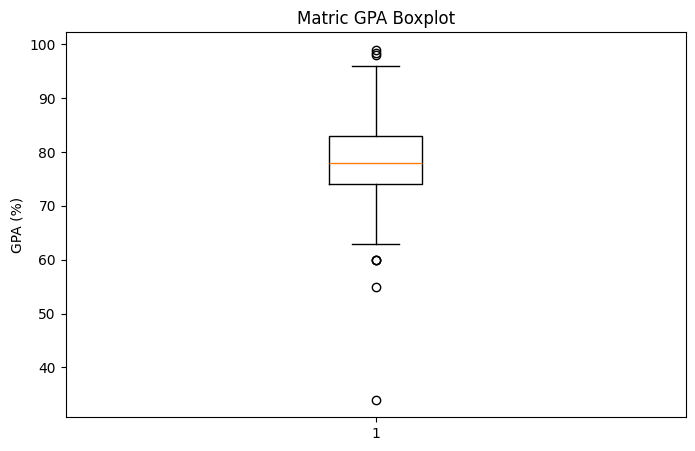

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    df["Your Matric (grade 12) Average/ GPA (in %)"]
)

plt.title("Matric GPA Boxplot")
plt.ylabel("GPA (%)")

plt.show()

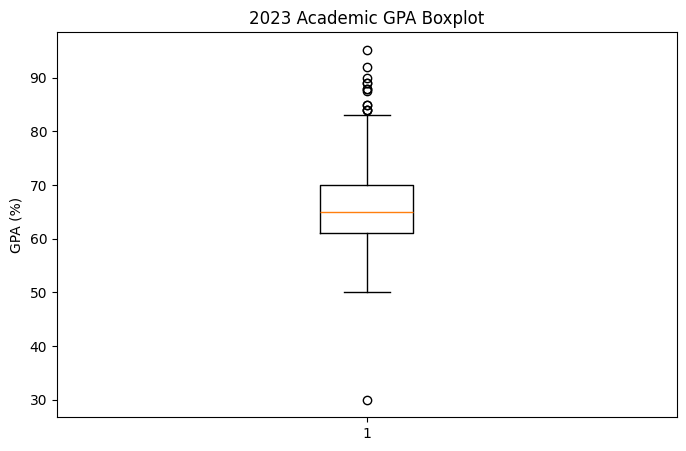

In [37]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    df["Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)"]
)

plt.title("2023 Academic GPA Boxplot")
plt.ylabel("GPA (%)")

plt.show()

In [38]:
for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

In [39]:
df[numeric_columns].describe()

,Your Matric (grade 12) Average/ GPA (in %),Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)
count,406.000000,406.000000
mean,78.058054,65.906626
std,6.599515,7.623212
min,60.500000,47.500000
25%,74.000000,61.000000
50%,78.000000,65.000000
75%,83.000000,70.000000
max,96.500000,83.500000


In [40]:
allowance_mapping = {
    "R 4001- R 5000": 4500,
    "R 5001 - R 6000": 5500,
    "R 6001 - R 7000": 6500,
    "R 7001 - R 8000": 7500,
    "R 8000+": 8500,
    "Unknown": np.nan
}

df["Monthly_Allowance_Numeric"] = (
    df["Monthly Allowance in 2023"]
    .map(allowance_mapping)
)

In [41]:
df[
    [
        "Monthly Allowance in 2023",
        "Monthly_Allowance_Numeric"
    ]
].head(10)

,Monthly Allowance in 2023,Monthly_Allowance_Numeric
0,R 4001- R 5000,4500.0
1,R 7001 - R 8000,7500.0
2,R 4001- R 5000,4500.0
3,R 6001 - R 7000,6500.0
4,R 4001- R 5000,4500.0
5,R 6001 - R 7000,6500.0
6,R 5001 - R 6000,5500.0
7,R 5001 - R 6000,5500.0
8,R 5001 - R 6000,5500.0
9,R 6001 - R 7000,6500.0


In [42]:
study_hours_mapping = {
    "0": 0,
    "1-3": 2,
    "3-5": 4,
    "5-8": 6.5,
    "8+": 9,
    "Unknown": np.nan
}

df["Study_Hours_Per_Week"] = (
    df["Additional amount of studying (in hrs) per week"]
    .map(study_hours_mapping)
)

In [43]:
df[
    [
        "Additional amount of studying (in hrs) per week",
        "Study_Hours_Per_Week"
    ]
].head()

,Additional amount of studying (in hrs) per week,Study_Hours_Per_Week
0,8+,9.0
1,8+,9.0
2,3-5,4.0
3,3-5,4.0
4,3-5,4.0


In [44]:
party_mapping = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4+": 4,
    "Only weekends": 1,
    "Unknown": np.nan
}

df["Party_Frequency_Per_Week"] = (
    df["How often do you go out partying/socialising during the week? "]
    .map(party_mapping)
)

In [45]:
df[
    [
        "How often do you go out partying/socialising during the week? ",
        "Party_Frequency_Per_Week"
    ]
].head(10)

,How often do you go out partying/socialising during the week?,Party_Frequency_Per_Week
0,Only weekends,1.0
1,Only weekends,1.0
2,2,2.0
3,3,3.0
4,Only weekends,1.0
5,4+,4.0
6,2,2.0
7,3,3.0
8,Only weekends,1.0
9,3,3.0


In [46]:
alcohol_mapping = {
    "0": 0,
    "1-3": 2,
    "3-5": 4,
    "5-8": 6.5,
    "8+": 9,
    "Unknown": np.nan
}

df["Alcohol_Drinks_Per_Night"] = (
    df["On a night out, how many alcoholic drinks do you consume?"]
    .map(alcohol_mapping)
)

In [47]:
df[
    [
        "On a night out, how many alcoholic drinks do you consume?",
        "Alcohol_Drinks_Per_Night"
    ]
].head()

,"On a night out, how many alcoholic drinks do you consume?",Alcohol_Drinks_Per_Night
0,8+,9.0
1,3-5,4.0
2,8+,9.0
3,8+,9.0
4,5-8,6.5


In [48]:
classes_mapping = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4+": 4,
    "Unknown": np.nan
}

df["Classes_Missed_Per_Week"] = (
    df[
        "How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)"
    ].map(classes_mapping)
)

In [49]:
failed_modules_mapping = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4+": 4,
    "Unknown": np.nan
}

df["Failed_Modules"] = (
    df[
        "How many modules have you failed thus far into your studies?"
    ].map(failed_modules_mapping)
)

In [50]:
parent_relationship_mapping = {
    "Distant": 1,
    "Fair": 2,
    "Close": 3,
    "Very close": 4,
    "Unknown": 0
}

df["Parent_Relationship_Score"] = (
    df["How strong is your relationship with your parent/s?"]
    .map(parent_relationship_mapping)
)

In [51]:
df["Scholarship"] = (
    df["Were you on scholarship/bursary in 2023?"]
    .map({
        "Yes (NSFAS, etc...)": 1,
        "No": 0,
        "Unknown": 0
    })
)

In [52]:
df["In_Relationship"] = (
    df["Are you currently in a romantic relationship?"]
    .map({
        "Yes": 1,
        "No": 0,
        "Unknown": 0
    })
)

In [53]:
df["Parents_Approve_Alcohol"] = (
    df["Do your parents approve alcohol consumption?"]
    .map({
        "Yes": 1,
        "No": 0,
        "Unknown": 0
    })
)

In [54]:
df["Alcohol_Exposure_Score"] = (
    df["Party_Frequency_Per_Week"] *
    df["Alcohol_Drinks_Per_Night"]
)

In [55]:
df["Alcohol_Exposure_Score"].describe()

,Alcohol_Exposure_Score
count,404.000000
mean,8.861386
std,8.075441
min,0.000000
25%,4.000000
50%,6.500000
75%,12.250000
max,36.000000


In [56]:
df["Academic_Risk_Score"] = (
    df["Classes_Missed_Per_Week"] +
    df["Failed_Modules"] -
    df["Study_Hours_Per_Week"] * 0.1
)

In [57]:
df.head()

,Your Sex?,Your Matric (grade 12) Average/ GPA (in %),What year were you in last year (2023) ?,What faculty does your degree fall under?,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Your Accommodation Status Last Year (2023),Monthly Allowance in 2023,Were you on scholarship/bursary in 2023?,Additional amount of studying (in hrs) per week,How often do you go out partying/socialising during the week?,...,Party_Frequency_Per_Week,Alcohol_Drinks_Per_Night,Classes_Missed_Per_Week,Failed_Modules,Parent_Relationship_Score,Scholarship,In_Relationship,Parents_Approve_Alcohol,Alcohol_Exposure_Score,Academic_Risk_Score
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,...,1.0,9.0,3.0,0.0,4,0,1,1,9.0,2.1
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,...,1.0,4.0,4.0,0.0,4,1,0,1,4.0,3.1
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,...,2.0,9.0,3.0,0.0,4,0,0,1,18.0,2.6
3,Male,89.0,2nd Year,Engineering,83.5,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,...,3.0,9.0,2.0,0.0,4,0,1,1,27.0,1.6
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,...,1.0,6.5,1.0,3.0,2,0,0,1,6.5,3.6


In [58]:
print(df.columns.tolist())

['Your Sex?', 'Your Matric (grade 12) Average/ GPA (in %)', 'What year were you in last year (2023) ?', 'What faculty does your degree fall under?', 'Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)', 'Your Accommodation Status Last Year (2023)', 'Monthly Allowance in 2023', 'Were you on scholarship/bursary in 2023?', 'Additional amount of studying (in hrs) per week', 'How often do you go out partying/socialising during the week? ', 'On a night out, how many alcoholic drinks do you consume?', 'How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)', 'How many modules have you failed thus far into your studies?', 'Are you currently in a romantic relationship?', 'Do your parents approve alcohol consumption?', 'How strong is your relationship with your parent/s?', 'Monthly_Allowance_Numeric', 'Study_Hours_Per_Week', 'Party_Frequency_Per_Week', 'Alcohol_Drinks_Per_Night', 'Classes_Missed_Per_Week', 'Failed_Modules

In [59]:
df.isnull().sum()

,0
Your Sex?,0
Your Matric (grade 12) Average/ GPA (in %),0
What year were you in last year (2023) ?,0
What faculty does your degree fall under?,0
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),0
Your Accommodation Status Last Year (2023),0
Monthly Allowance in 2023,0
Were you on scholarship/bursary in 2023?,0
Additional amount of studying (in hrs) per week,0
How often do you go out partying/socialising during the week?,0


In [60]:
engineered_numeric = [
    "Monthly_Allowance_Numeric",
    "Study_Hours_Per_Week",
    "Party_Frequency_Per_Week",
    "Alcohol_Drinks_Per_Night",
    "Classes_Missed_Per_Week",
    "Failed_Modules",
    "Parent_Relationship_Score",
    "Scholarship",
    "In_Relationship",
    "Parents_Approve_Alcohol",
    "Alcohol_Exposure_Score",
    "Academic_Risk_Score"
]

for column in engineered_numeric:
    df[column] = df[column].fillna(df[column].median())

In [61]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [62]:
columns_to_remove = [
    "Monthly Allowance in 2023",
    "Additional amount of studying (in hrs) per week",
    "How often do you go out partying/socialising during the week? ",
    "On a night out, how many alcoholic drinks do you consume?",
    "How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)",
    "How many modules have you failed thus far into your studies?",
    "How strong is your relationship with your parent/s?",
    "Were you on scholarship/bursary in 2023?",
    "Are you currently in a romantic relationship?",
    "Do your parents approve alcohol consumption?"
]

In [63]:
ml_df = df.drop(columns=columns_to_remove)

In [64]:
ml_df.head()

,Your Sex?,Your Matric (grade 12) Average/ GPA (in %),What year were you in last year (2023) ?,What faculty does your degree fall under?,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Your Accommodation Status Last Year (2023),Monthly_Allowance_Numeric,Study_Hours_Per_Week,Party_Frequency_Per_Week,Alcohol_Drinks_Per_Night,Classes_Missed_Per_Week,Failed_Modules,Parent_Relationship_Score,Scholarship,In_Relationship,Parents_Approve_Alcohol,Alcohol_Exposure_Score,Academic_Risk_Score
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,4500.0,9.0,1.0,9.0,3.0,0.0,4,0,1,1,9.0,2.1
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,7500.0,9.0,1.0,4.0,4.0,0.0,4,1,0,1,4.0,3.1
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,4500.0,4.0,2.0,9.0,3.0,0.0,4,0,0,1,18.0,2.6
3,Male,89.0,2nd Year,Engineering,83.5,Private accommodation/ stay with family/friends,6500.0,4.0,3.0,9.0,2.0,0.0,4,0,1,1,27.0,1.6
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,4500.0,4.0,1.0,6.5,1.0,3.0,2,0,0,1,6.5,3.6


In [65]:
categorical_features = ml_df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_features)

Categorical columns:
['Your Sex?', 'What year were you in last year (2023) ?', 'What faculty does your degree fall under?', 'Your Accommodation Status Last Year (2023)']


In [66]:
ml_df_encoded = pd.get_dummies(
    ml_df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

In [67]:
ml_df_encoded.head()

,Your Matric (grade 12) Average/ GPA (in %),Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Monthly_Allowance_Numeric,Study_Hours_Per_Week,Party_Frequency_Per_Week,Alcohol_Drinks_Per_Night,Classes_Missed_Per_Week,Failed_Modules,Parent_Relationship_Score,Scholarship,...,What faculty does your degree fall under?_Arts & Social Sciences,What faculty does your degree fall under?_Economic & Management Sciences,What faculty does your degree fall under?_Education,What faculty does your degree fall under?_Engineering,What faculty does your degree fall under?_Law,What faculty does your degree fall under?_Medicine and Health Services,What faculty does your degree fall under?_Science,What faculty does your degree fall under?_Unknown,Your Accommodation Status Last Year (2023)_Private accommodation/ stay with family/friends,Your Accommodation Status Last Year (2023)_Unknown
0,76.0,72.0,4500.0,9.0,1.0,9.0,3.0,0.0,4,0,...,1,0,0,0,0,0,0,0,1,0
1,89.0,75.0,7500.0,9.0,1.0,4.0,4.0,0.0,4,1,...,0,1,0,0,0,0,0,0,1,0
2,76.0,55.0,4500.0,4.0,2.0,9.0,3.0,0.0,4,0,...,0,0,0,0,0,0,0,0,1,0
3,89.0,83.5,6500.0,4.0,3.0,9.0,2.0,0.0,4,0,...,0,0,0,1,0,0,0,0,1,0
4,74.0,52.0,4500.0,4.0,1.0,6.5,1.0,3.0,2,0,...,1,0,0,0,0,0,0,0,1,0


In [68]:
print("Rows:", ml_df_encoded.shape[0])
print("Columns:", ml_df_encoded.shape[1])

Rows: 406
Columns: 31


In [69]:
# Check data types

ml_df_encoded.dtypes.value_counts()

,count
int64,21
float64,10


In [70]:
print(
    "Number of non-numeric columns:",
    len(ml_df_encoded.select_dtypes(exclude=np.number).columns)
)

Number of non-numeric columns: 0


In [71]:
# Normalization

from sklearn.preprocessing import StandardScaler

In [72]:
numeric_features = ml_df_encoded.select_dtypes(
    include=np.number
).columns

In [73]:
scaler = StandardScaler()

ml_df_encoded[numeric_features] = scaler.fit_transform(
    ml_df_encoded[numeric_features]
)

In [74]:
ml_df_encoded.head()

,Your Matric (grade 12) Average/ GPA (in %),Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Monthly_Allowance_Numeric,Study_Hours_Per_Week,Party_Frequency_Per_Week,Alcohol_Drinks_Per_Night,Classes_Missed_Per_Week,Failed_Modules,Parent_Relationship_Score,Scholarship,...,What faculty does your degree fall under?_Arts & Social Sciences,What faculty does your degree fall under?_Economic & Management Sciences,What faculty does your degree fall under?_Education,What faculty does your degree fall under?_Engineering,What faculty does your degree fall under?_Law,What faculty does your degree fall under?_Medicine and Health Services,What faculty does your degree fall under?_Science,What faculty does your degree fall under?_Unknown,Your Accommodation Status Last Year (2023)_Private accommodation/ stay with family/friends,Your Accommodation Status Last Year (2023)_Unknown
0,-0.312234,0.800305,-0.922228,1.293936,-0.644196,1.414298,1.671698,-0.603657,0.620844,-0.357460,...,2.763747,-1.040217,-0.122474,-0.316656,-0.15891,-0.15891,-0.4,-0.132453,0.46037,-0.245056
1,1.660038,1.194325,1.596323,1.293936,-0.644196,-0.372832,2.482581,-0.603657,0.620844,2.797514,...,-0.361828,0.961338,-0.122474,-0.316656,-0.15891,-0.15891,-0.4,-0.132453,0.46037,-0.245056
2,-0.312234,-1.432478,-0.922228,-0.453114,0.427704,1.414298,1.671698,-0.603657,0.620844,-0.357460,...,-0.361828,-1.040217,-0.122474,-0.316656,-0.15891,-0.15891,-0.4,-0.132453,0.46037,-0.245056
3,1.660038,2.310716,0.756806,-0.453114,1.499605,1.414298,0.860815,-0.603657,0.620844,-0.357460,...,-0.361828,-1.040217,-0.122474,3.158001,-0.15891,-0.15891,-0.4,-0.132453,0.46037,-0.245056
4,-0.615661,-1.826498,-0.922228,-0.453114,-0.644196,0.520733,0.049931,1.847191,-2.104157,-0.357460,...,2.763747,-1.040217,-0.122474,-0.316656,-0.15891,-0.15891,-0.4,-0.132453,0.46037,-0.245056


In [75]:
# Check normalization

print(
    ml_df_encoded[numeric_features].mean().round(2).head(10)
)

Your Matric (grade 12) Average/ GPA (in %)                                            0.0
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)    0.0
Monthly_Allowance_Numeric                                                            -0.0
Study_Hours_Per_Week                                                                 -0.0
Party_Frequency_Per_Week                                                              0.0
Alcohol_Drinks_Per_Night                                                              0.0
Classes_Missed_Per_Week                                                               0.0
Failed_Modules                                                                        0.0
Parent_Relationship_Score                                                            -0.0
Scholarship                                                                           0.0
dtype: float64


In [76]:
print(
    ml_df_encoded[numeric_features].std().round(2).head(10)
)

Your Matric (grade 12) Average/ GPA (in %)                                            1.0
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)    1.0
Monthly_Allowance_Numeric                                                             1.0
Study_Hours_Per_Week                                                                  1.0
Party_Frequency_Per_Week                                                              1.0
Alcohol_Drinks_Per_Night                                                              1.0
Classes_Missed_Per_Week                                                               1.0
Failed_Modules                                                                        1.0
Parent_Relationship_Score                                                             1.0
Scholarship                                                                           1.0
dtype: float64


In [79]:
# Post processing checks

print("Dataset shape:", ml_df_encoded.shape)

Dataset shape: (406, 31)


In [80]:
print(
    "Total missing values:",
    ml_df_encoded.isnull().sum().sum()
)

Total missing values: 0


In [81]:
print(
    "Duplicate rows:",
    ml_df_encoded.duplicated().sum()
)

Duplicate rows: 3


In [82]:
ml_df_encoded = ml_df_encoded.drop_duplicates()

In [83]:
# Final validation

print("Final shape:", ml_df_encoded.shape)

print(
    "Missing values:",
    ml_df_encoded.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    ml_df_encoded.duplicated().sum()
)

print(
    "Non-numeric columns:",
    len(ml_df_encoded.select_dtypes(exclude=np.number).columns)
)

Final shape: (403, 31)
Missing values: 0
Duplicate rows: 0
Non-numeric columns: 0


In [85]:
# Save your clean dataset

df.to_csv(
    "survey_student_cleaned_feature_engineered.csv",
    index=False
)

In [86]:
ml_df_encoded.to_csv(
    "survey_student_ml_ready.csv",
    index=False
)

In [87]:
# Download the files from Colab

from google.colab import files

files.download(
    "survey_student_cleaned_feature_engineered.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [88]:
files.download(
    "survey_student_ml_ready.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [90]:
# EDA - Exploratory Data Analysis

In [100]:
# Import EDA Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
sns.set_theme(style="whitegrid")

In [102]:
# Check your cleaned dataset

df.head()

,Your Sex?,Your Matric (grade 12) Average/ GPA (in %),What year were you in last year (2023) ?,What faculty does your degree fall under?,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Your Accommodation Status Last Year (2023),Monthly Allowance in 2023,Were you on scholarship/bursary in 2023?,Additional amount of studying (in hrs) per week,How often do you go out partying/socialising during the week?,...,Alcohol_Drinks_Per_Night,Classes_Missed_Per_Week,Failed_Modules,Parent_Relationship_Score,Scholarship,In_Relationship,Parents_Approve_Alcohol,Alcohol_Exposure_Score,Academic_Risk_Score,Study_Hours
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,...,9.0,3.0,0.0,4,0,1,1,9.0,2.1,9.0
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,...,4.0,4.0,0.0,4,1,0,1,4.0,3.1,9.0
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,...,9.0,3.0,0.0,4,0,0,1,18.0,2.6,4.0
3,Male,89.0,2nd Year,Engineering,83.5,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,...,9.0,2.0,0.0,4,0,1,1,27.0,1.6,4.0
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,...,6.5,1.0,3.0,2,0,0,1,6.5,3.6,4.0


In [103]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 406
Columns: 29


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 29 columns):
 #   Column                                                                                             Non-Null Count  Dtype  
---  ------                                                                                             --------------  -----  
 0   Your Sex?                                                                                          406 non-null    object 
 1   Your Matric (grade 12) Average/ GPA (in %)                                                         406 non-null    float64
 2   What year were you in last year (2023) ?                                                           406 non-null    object 
 3   What faculty does your degree fall under?                                                          406 non-null    object 
 4   Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)                 406 non-null    float64

In [105]:
# Check missing values one last time

df.isnull().sum()

,0
Your Sex?,0
Your Matric (grade 12) Average/ GPA (in %),0
What year were you in last year (2023) ?,0
What faculty does your degree fall under?,0
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),0
Your Accommodation Status Last Year (2023),0
Monthly Allowance in 2023,0
Were you on scholarship/bursary in 2023?,0
Additional amount of studying (in hrs) per week,0
How often do you go out partying/socialising during the week?,0


In [106]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 3


In [107]:
# Create the numerical variables needed for EDA

study_mapping = {
    "0": 0,
    "1-3": 2,
    "3-5": 4,
    "5-8": 6.5,
    "8+": 9
}

df["Study_Hours"] = (
    df["Additional amount of studying (in hrs) per week"]
    .map(study_mapping)
)

In [108]:
df[[
    "Additional amount of studying (in hrs) per week",
    "Study_Hours"
]].head()

,Additional amount of studying (in hrs) per week,Study_Hours
0,8+,9.0
1,8+,9.0
2,3-5,4.0
3,3-5,4.0
4,3-5,4.0


In [109]:
# Convert alcohol consumption to numerical values

alcohol_mapping = {
    "0": 0,
    "1-3": 2,
    "3-5": 4,
    "5-8": 6.5,
    "8+": 9
}

df["Alcohol_Drinks"] = (
    df["On a night out, how many alcoholic drinks do you consume?"]
    .map(alcohol_mapping)
)

In [110]:
df[[
    "On a night out, how many alcoholic drinks do you consume?",
    "Alcohol_Drinks"
]].head()

,"On a night out, how many alcoholic drinks do you consume?",Alcohol_Drinks
0,8+,9.0
1,3-5,4.0
2,8+,9.0
3,8+,9.0
4,5-8,6.5


In [112]:
# Convert missed classes to numerical values

missed_class_mapping = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4+": 4
}

df["Missed_Classes"] = (
    df[
        "How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)"
    ].map(missed_class_mapping)
)

In [113]:
df[[
    "How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)",
    "Missed_Classes"
]].head()

,"How many classes do you miss per week due to alcohol reasons, (i.e: being hungover or too tired?)",Missed_Classes
0,3,3.0
1,4+,4.0
2,3,3.0
3,2,2.0
4,1,1.0


In [114]:
# Convert failed modules to numerical values

failed_mapping = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4+": 4
}

df["Failed_Modules"] = (
    df[
        "How many modules have you failed thus far into your studies?"
    ].map(failed_mapping)
)

In [115]:
df[[
    "How many modules have you failed thus far into your studies?",
    "Failed_Modules"
]].head()

,How many modules have you failed thus far into your studies?,Failed_Modules
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,3,3.0


In [116]:
# Check the variables we're going to use

eda_columns = [
    "Study_Hours",
    "Alcohol_Drinks",
    "Missed_Classes",
    "Failed_Modules"
]

df[eda_columns].describe()

,Study_Hours,Alcohol_Drinks,Missed_Classes,Failed_Modules
count,403.000000,404.000000,403.000000,403.000000
mean,5.306452,5.048267,0.945409,0.744417
std,2.873971,2.807208,1.236669,1.228471
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,0.000000
50%,4.000000,4.000000,0.000000,0.000000
75%,9.000000,6.500000,2.000000,1.000000
max,9.000000,9.000000,4.000000,4.000000


In [117]:
# EDA 1 — BAR CHART

faculty_column = "What faculty does your degree fall under?"

df[faculty_column].value_counts()

,count
What faculty does your degree fall under?,
Economic & Management Sciences,211
Science,56
Arts & Social Sciences,47
Engineering,37
AgriSciences,22
Medicine and Health Services,10
Law,10
Unknown,7
Education,6


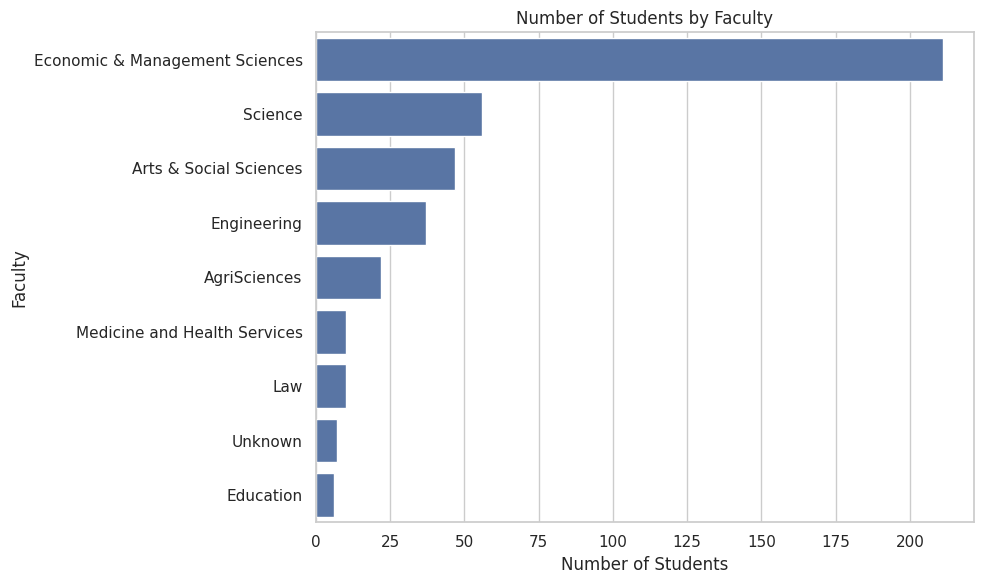

In [118]:
plt.figure(figsize=(10, 6))

faculty_counts = df[faculty_column].value_counts()

sns.barplot(
    x=faculty_counts.values,
    y=faculty_counts.index
)

plt.title("Number of Students by Faculty")
plt.xlabel("Number of Students")
plt.ylabel("Faculty")

plt.tight_layout()
plt.show()

In [119]:
# EDA 2 — LINE GRAPH

year_column = "What year were you in last year (2023) ?"

academic_gpa = "Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)"

In [120]:
df[academic_gpa] = pd.to_numeric(
    df[academic_gpa],
    errors="coerce"
)

In [121]:
year_gpa = (
    df.groupby(year_column)[academic_gpa]
      .mean()
      .sort_index()
)

year_gpa

,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)
What year were you in last year (2023) ?,
1st Year,66.933594
2nd Year,65.304510
3rd Year,65.762500
4th Year,68.071429
Postgraduate,70.400000
Unknown,64.931507


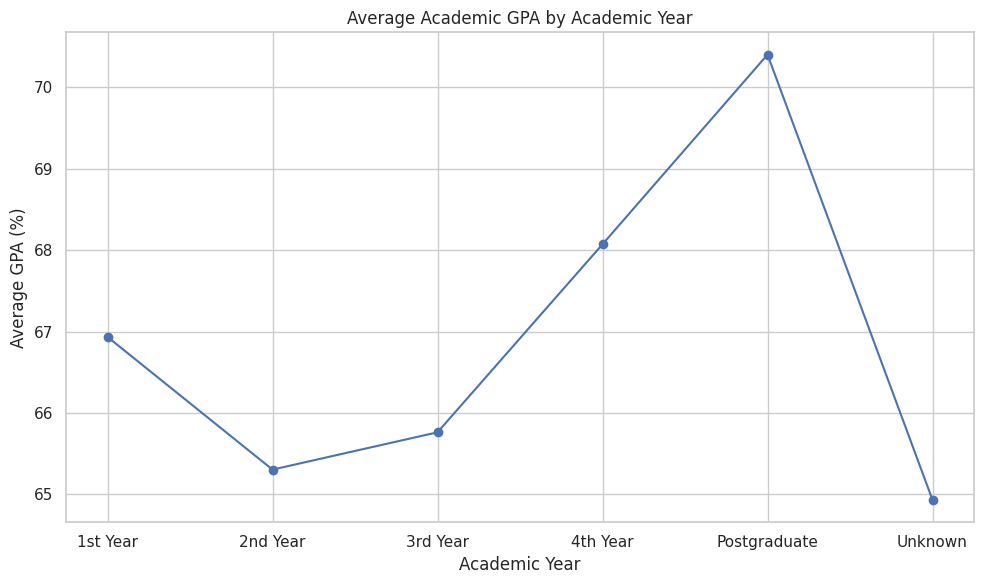

In [122]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_gpa.index.astype(str),
    year_gpa.values,
    marker="o"
)

plt.title("Average Academic GPA by Academic Year")
plt.xlabel("Academic Year")
plt.ylabel("Average GPA (%)")

plt.tight_layout()
plt.show()

In [123]:
# EDA 3 — SCATTERPLOT

scatter_df = df[
    ["Study_Hours", academic_gpa]
].dropna()

In [124]:
scatter_df.head()

,Study_Hours,Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)
0,9.0,72.0
1,9.0,75.0
2,4.0,55.0
3,4.0,83.5
4,4.0,52.0


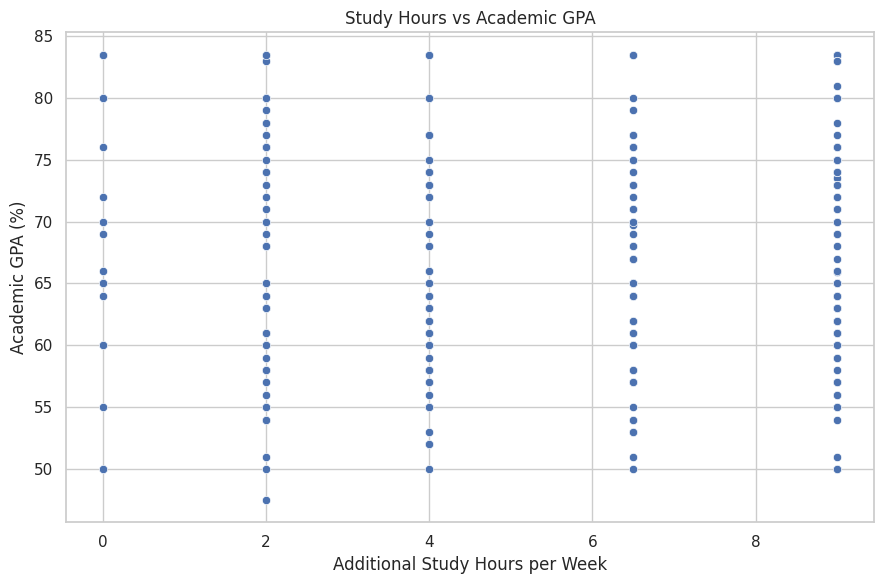

In [125]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=scatter_df,
    x="Study_Hours",
    y=academic_gpa
)

plt.title("Study Hours vs Academic GPA")
plt.xlabel("Additional Study Hours per Week")
plt.ylabel("Academic GPA (%)")

plt.tight_layout()
plt.show()

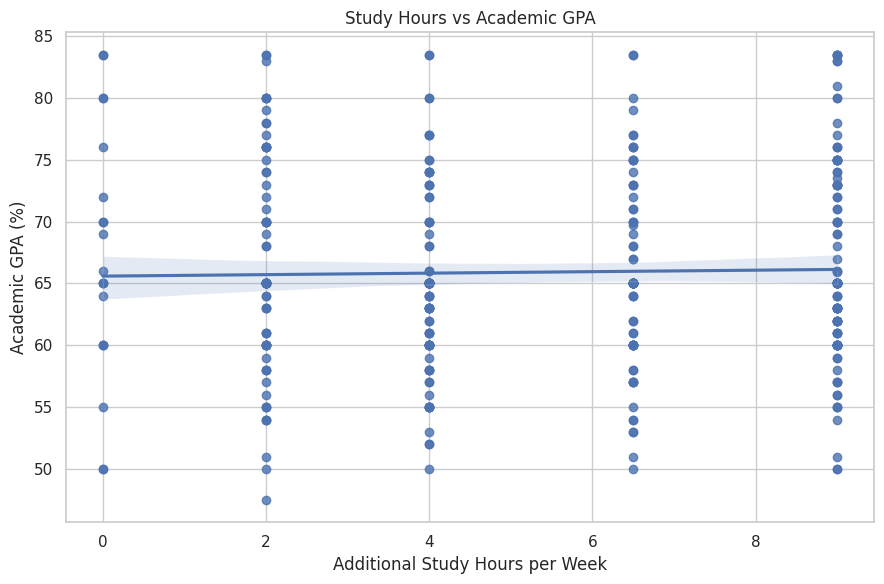

In [126]:
# Add a trend line

plt.figure(figsize=(9, 6))

sns.regplot(
    data=scatter_df,
    x="Study_Hours",
    y=academic_gpa
)

plt.title("Study Hours vs Academic GPA")
plt.xlabel("Additional Study Hours per Week")
plt.ylabel("Academic GPA (%)")

plt.tight_layout()
plt.show()

In [127]:
# EDA 4 — HEATMAP

matric_gpa = "Your Matric (grade 12) Average/ GPA (in %)"

In [128]:
df[matric_gpa] = pd.to_numeric(
    df[matric_gpa],
    errors="coerce"
)

In [129]:
correlation_columns = [
    matric_gpa,
    academic_gpa,
    "Study_Hours",
    "Alcohol_Drinks",
    "Missed_Classes",
    "Failed_Modules"
]

corr_df = df[correlation_columns]

In [130]:
# Calculate the correlation matrix

correlation_matrix = corr_df.corr()

correlation_matrix

,Your Matric (grade 12) Average/ GPA (in %),Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),Study_Hours,Alcohol_Drinks,Missed_Classes,Failed_Modules
Your Matric (grade 12) Average/ GPA (in %),1.000000,0.234068,0.225470,-0.114371,0.027952,-0.115792
Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student),0.234068,1.000000,0.022547,-0.055859,-0.081113,-0.404954
Study_Hours,0.225470,0.022547,1.000000,-0.093575,-0.106073,-0.017079
Alcohol_Drinks,-0.114371,-0.055859,-0.093575,1.000000,0.380379,0.054215
Missed_Classes,0.027952,-0.081113,-0.106073,0.380379,1.000000,0.065036
Failed_Modules,-0.115792,-0.404954,-0.017079,0.054215,0.065036,1.000000


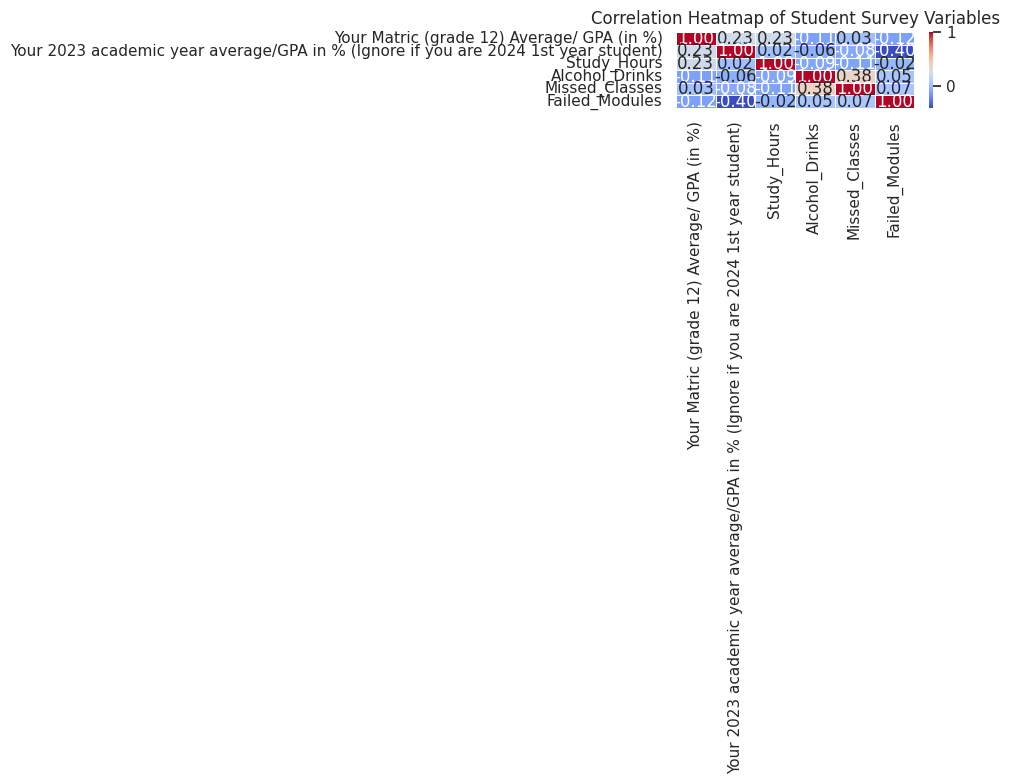

In [132]:
# Create the heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Student Survey Variables")

plt.tight_layout()
plt.show()

In [133]:
# EDA 5 — BOX PLOT

alcohol_order = [
    "0",
    "1-3",
    "3-5",
    "5-8",
    "8+"
]

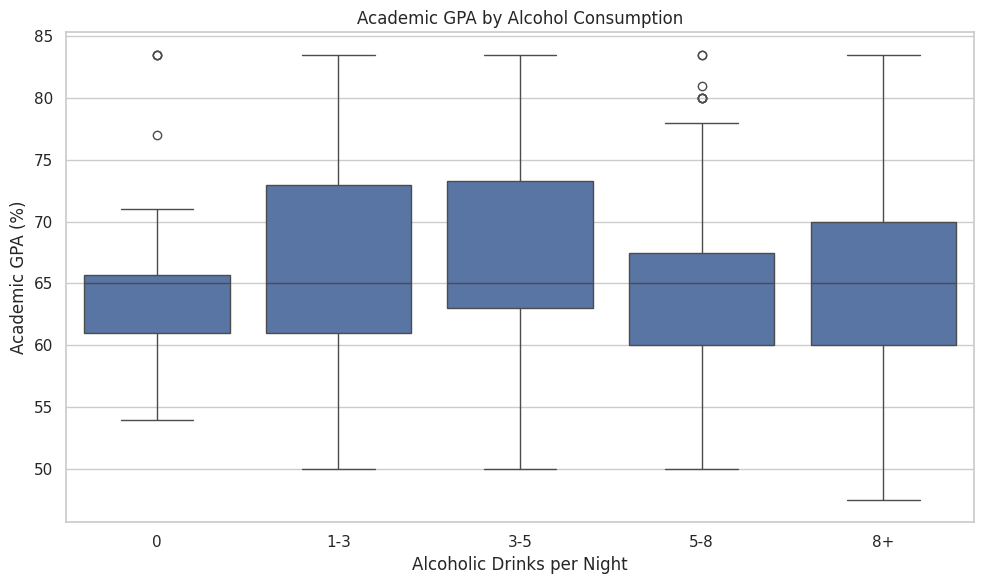

In [134]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="On a night out, how many alcoholic drinks do you consume?",
    y=academic_gpa,
    order=alcohol_order
)

plt.title("Academic GPA by Alcohol Consumption")
plt.xlabel("Alcoholic Drinks per Night")
plt.ylabel("Academic GPA (%)")

plt.tight_layout()
plt.show()

In [135]:
# Create one additional scatterplot

alcohol_class_df = df[
    ["Alcohol_Drinks", "Missed_Classes"]
].dropna()

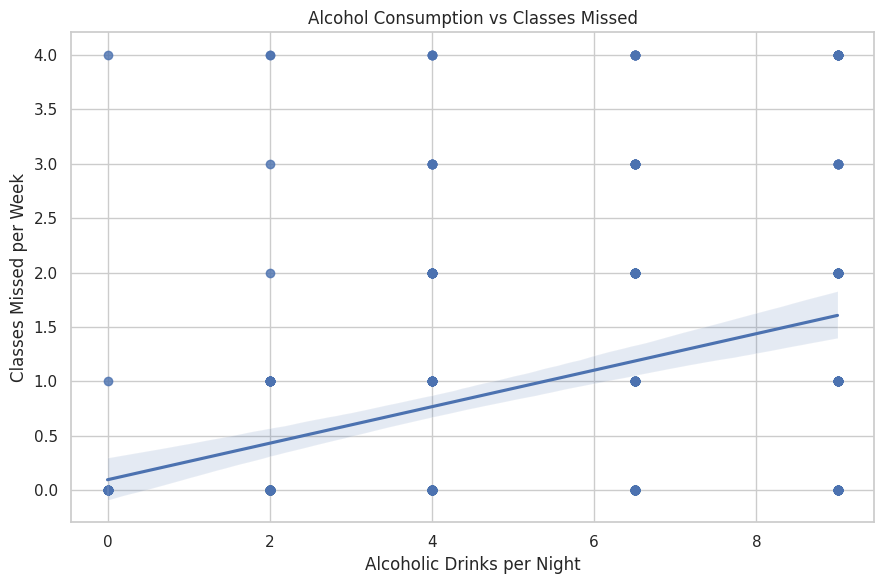

In [136]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=alcohol_class_df,
    x="Alcohol_Drinks",
    y="Missed_Classes"
)

plt.title("Alcohol Consumption vs Classes Missed")
plt.xlabel("Alcoholic Drinks per Night")
plt.ylabel("Classes Missed per Week")

plt.tight_layout()
plt.show()

In [137]:
# Save your clean student survey file

df.to_csv(
    "clean_student_survey.csv",
    index=False
)

In [138]:
import os

print(os.path.exists("clean_student_survey.csv"))

True


In [139]:
# Download the clean CSV

from google.colab import files

files.download("clean_student_survey.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>